<a href="https://colab.research.google.com/github/StillWork/6GMP/blob/main/GMP_AI_%E1%84%8B%E1%85%A8%E1%84%8C%E1%85%A67_%E1%84%80%E1%85%A9%E1%86%BC%E1%84%8C%E1%85%A5%E1%86%BC%E1%84%89%E1%85%A1%E1%86%BC%E1%84%90%E1%85%A2_%E1%84%91%E1%85%A2%E1%84%90%E1%85%A5%E1%86%AB%E1%84%8B%E1%85%B5%E1%86%AB%E1%84%89%E1%85%B5%E1%86%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 예제 7 — 공정 상태 공정 상태 패턴 인식 (시계열 딥러닝)

## 개요

시계열 센서 데이터로부터
**6가지 공정 상태**를 예측합니다.

| GMP 공정 상태 |  진동 특성 | 적용 설비 |
|-------------|---------|---------|
| **Compression** |  고주파·고진폭 규칙 진동 | 정제 압축기 정상 생산 |
| **Mixing** |  중주파·중진폭 규칙 진동 | 혼합기/과립기 운전 |
| **Startup** |  진폭 점진적 증가 | 모터 기동 구간 |
| **Shutdown** |  진폭 점진적 감소 | 모터 정지 구간 |
| **CIP** |  저진폭·불규칙 | CIP/WFI 세척 중 |
| **Standby** |  준정적 (≈0g) | 대기/가동 준비 |


### 학습 목표
- 센서 시계열 데이터에 대해 CNN (Conv1D) 공정 상태 패턴 인식 방식 이해
- GMP PAT(Process Analytical Technology) 실무 적용법 습득
- 선형모델(SGD), RandomForest, MLP, CNN(Conv1D) 성능 비교

# import

---
## 📍 모듈 ④ — 공정 모니터링 | 예제 7: 시계열 공정 상태 패턴 인식

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **FDA PAT Guidance (2004)** | 공정 분석 기술 — 실시간 공정 상태 분류가 PAT의 핵심 응용 |
| **ICH Q8(R2) Real-Time Monitoring** | 제조 중 공정 상태 실시간 파악 → 즉각적 공정 개입 |
| **EU GMP Annex 11** | 전산화 시스템 검증 — AI 분류 모델의 소프트웨어 검증(GAMP 5) 필요 |
| **ICH Q10 지속적 공정 검증 (CPV)** | 배치 간 공정 상태 변화 추적 → 공정 안정성 유지 |

### 🤖 AI 도입 장점
| 전통 방법 | AI / 데이터 과학 방법 | 개선 효과 |
|---------|-------------------|---------|
| 사람이 트렌드 차트를 육안 판독 | **Conv1D CNN**: 원시 시계열에서 특성 자동 추출 | 24/7 자동 모니터링 |
| 단순 임계치(Threshold) 비교 | 6가지 공정 상태를 복잡한 패턴으로 구분 | 임계치로 불가능한 복잡 상태 분류 |
| 도메인 전문가의 특성 수동 설계 | 1D 합성곱 필터가 패턴 자동 학습 | 특성 설계 비용 제거 |

### 🎯 핵심 Takeaway
> **"딥러닝 1D-CNN은 도메인 지식 없이도 시계열 패턴을 스스로 학습한다."**

1. **Conv1D (1차원 합성곱)**: 이미지에서 2D 패턴을 찾듯, 시계열에서 **시간적 패턴**을 자동 추출  
   → 수작업 특성 설계(Feature Engineering) 없이 원시 센서 데이터 직접 처리
2. 공정 상태 분류 정확도 > 95%이면 **PAT 자동 판별 시스템** 구축 가능  
   → 오퍼레이터 판단 의존도 감소, 24시간 무인 모니터링 실현
3. 이 예제의 HAR 데이터 → GMP 공정 상태 매핑은 **도메인 전환(Transfer Learning)** 개념의 선례  
   → 의약품 공정 데이터가 부족할 때 유사 도메인 데이터 활용 가능

### ➡️ 다음 예제
**예제 8 (예지보수)**: 공정 상태 분류(현재)를 넘어 설비 **고장 시점을 미리 예측**(미래)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

import warnings, zipfile
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn import preprocessing, metrics
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import matplotlib
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum -q 2>/dev/null

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Reshape
from keras.utils import to_categorical

print("✅ 라이브러리 로드 완료")

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (20.5 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 라이브러리 로드 완료


# 데이터 다운로드 및 로딩

## 데이터 구조
- **샘플링**: 20Hz (50ms 간격)
- **컬럼**: `batch`, `state`, `time`, `s1`, `s2`, `s3`

```
batch : 피험자(설비) 번호  — 훈련/검증 분리 기준
state : GMP 공정 상태     — 분류 목표 (CIP / Compression / Mixing / Shutdown / Standby / Startup)
time  : 타임스탬프 (ms)
s1, s2, s3 : 센서
```

In [2]:
# 센서 데이터 다운로드
!curl https://raw.githubusercontent.com/StillWork/data/master/sensor_pattern.zip \
    -o sensor_pattern.zip -s --show-error
print("✅ 다운로드 완료")

✅ 다운로드 완료


In [3]:
# 압축 풀기
with zipfile.ZipFile("sensor_pattern.zip", 'r') as z:
    print("파일 목록:", z.namelist())
    z.extractall()
print("✅ 압축 해제 완료")

파일 목록: ['sensor_pattern.txt', '__MACOSX/._sensor_pattern.txt']
✅ 압축 해제 완료


In [4]:
# 데이터 로딩
column_names = ['batch', 'state', 'time', 's1', 's2', 's3']
df = pd.read_csv('sensor_pattern.txt',
                 header=None, names=column_names)


print(f"✅ 데이터 로딩 완료: {df.shape}")
print(f"   배치(batch) 수: {df['batch'].nunique()}")
print(f"   공정 상태 종류: {sorted(df['state'].unique())}")
df.head()

✅ 데이터 로딩 완료: (1073629, 6)
   배치(batch) 수: 36
   공정 상태 종류: ['CIP', 'Compression', 'Mixing', 'Shutdown', 'Standby', 'Startup']


,batch,state,time,s1,s2,s3
0,33,Compression,49106062271000,5.012288,11.264028,0.953424
1,33,Compression,49106112167000,4.903325,10.882658,-0.081722
2,33,Compression,49106222305000,-0.612916,18.496431,3.023717
3,33,Compression,49106332290000,-1.184970,12.108489,7.205164
4,33,Compression,49106442306000,1.375655,-2.492524,-6.510526


## 💻 [셀 설명] 공정 상태 확인

`state` 컬럼에서 직접 상태 목록을 확인하고, 이후 코드에서 사용할 **레이블 리스트**를 만듭니다.

```
state 컬럼 값  →  분류 모델의 출력 클래스
CIP           →  0  (LabelEncoder 알파벳 정렬)
Compression   →  1
Mixing        →  2
Shutdown      →  3
Standby       →  4
Startup       →  5
```

In [5]:
# GMP 공정 상태 목록 확인 (LabelEncoder 기준 알파벳 정렬)
GMP_STATES = sorted(df['state'].unique())
print("GMP 공정 상태 목록:", GMP_STATES)
print(f"총 {len(GMP_STATES)}가지 공정 상태")

GMP 공정 상태 목록: ['CIP', 'Compression', 'Mixing', 'Shutdown', 'Standby', 'Startup']
총 6가지 공정 상태


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1073629 entries, 0 to 1073628
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   batch   1073629 non-null  int64  
 1   state   1073629 non-null  object 
 2   time    1073629 non-null  int64  
 3   s1      1073629 non-null  float64
 4   s2      1073629 non-null  float64
 5   s3      1073629 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 57.3+ MB


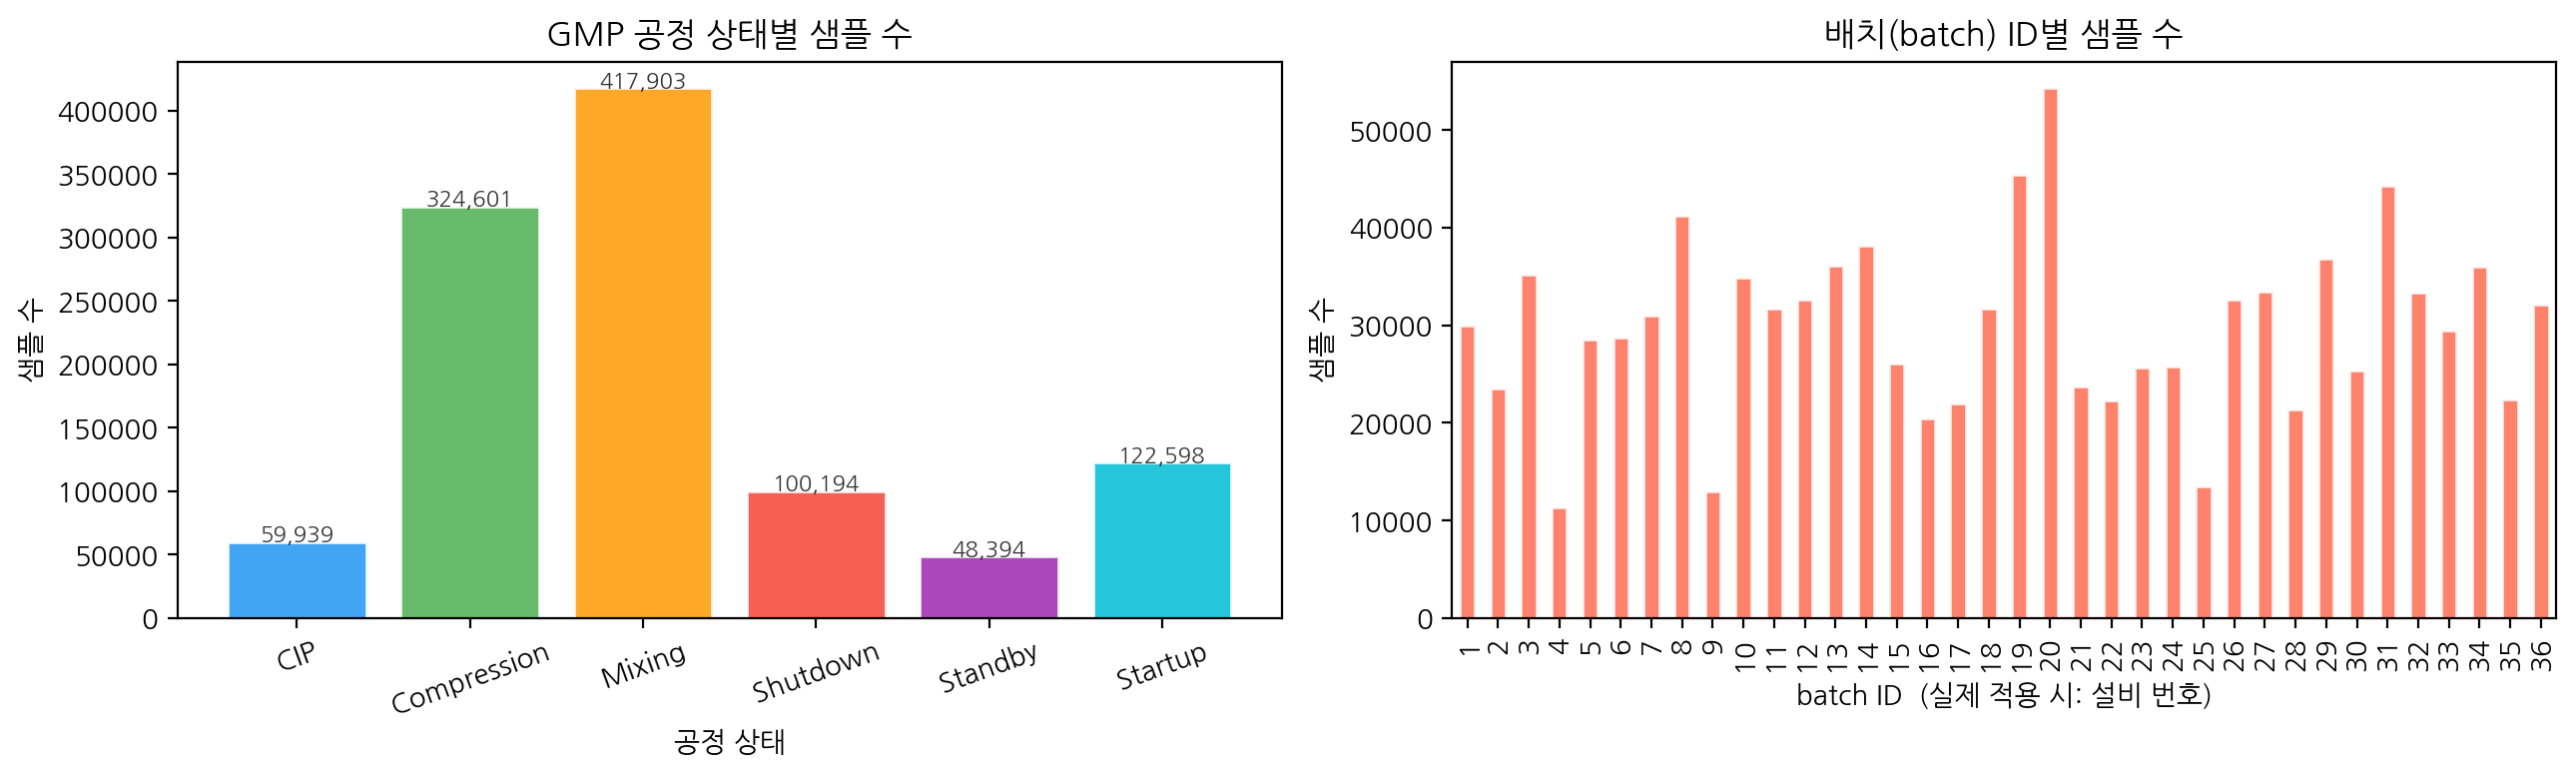

전체 샘플: 1,073,629개  |  batch 수: 36


In [7]:
# 공정 상태별 · 배치별 데이터 분포
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# GMP 상태별 샘플 수
counts = df['state'].value_counts().sort_index()
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4']
axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], alpha=0.85, edgecolor='white')
axes[0].set_title('GMP 공정 상태별 샘플 수', fontsize=12, fontweight='bold')
axes[0].set_xlabel('공정 상태')
axes[0].set_ylabel('샘플 수')
axes[0].tick_params(axis='x', rotation=20)
for j, (state, cnt) in enumerate(counts.items()):
    axes[0].text(j, cnt + 300, f'{cnt:,}', ha='center', fontsize=8, color='#333')

# 배치(batch)별 샘플 수
df['batch'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='tomato', alpha=0.8, edgecolor='white')
axes[1].set_title('배치(batch) ID별 샘플 수', fontsize=12, fontweight='bold')
axes[1].set_xlabel('batch ID  (실제 적용 시: 설비 번호)')
axes[1].set_ylabel('샘플 수')

plt.tight_layout()
plt.show()

print(f"전체 샘플: {len(df):,}개  |  batch 수: {df['batch'].nunique()}")

## 공정 상태별 센서 신호 시각화

HAR 동작과 GMP 공정 상태를 나란히 보여 매핑의 직관성을 확인합니다.

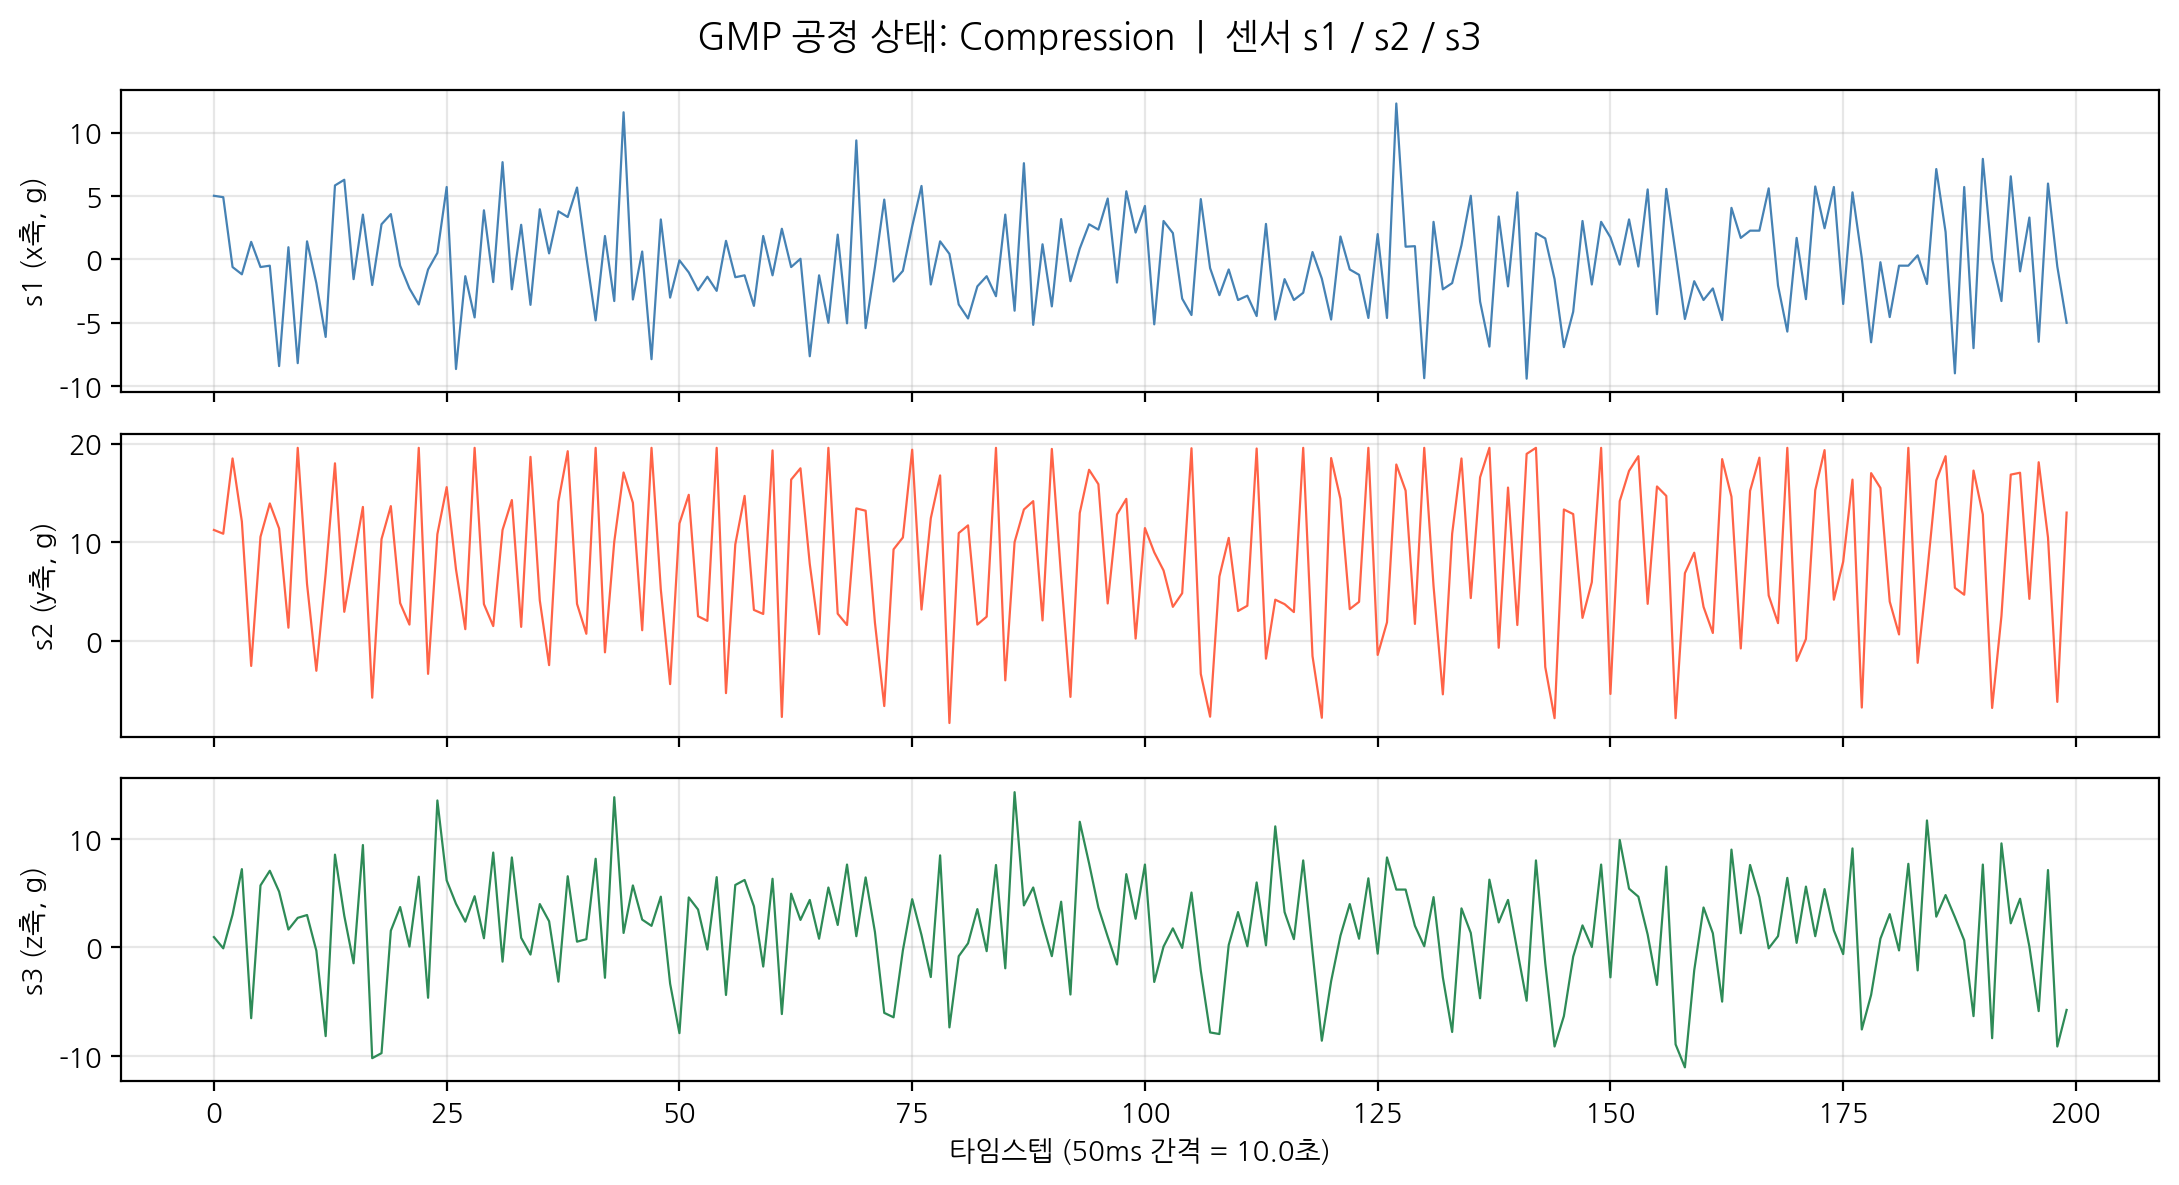

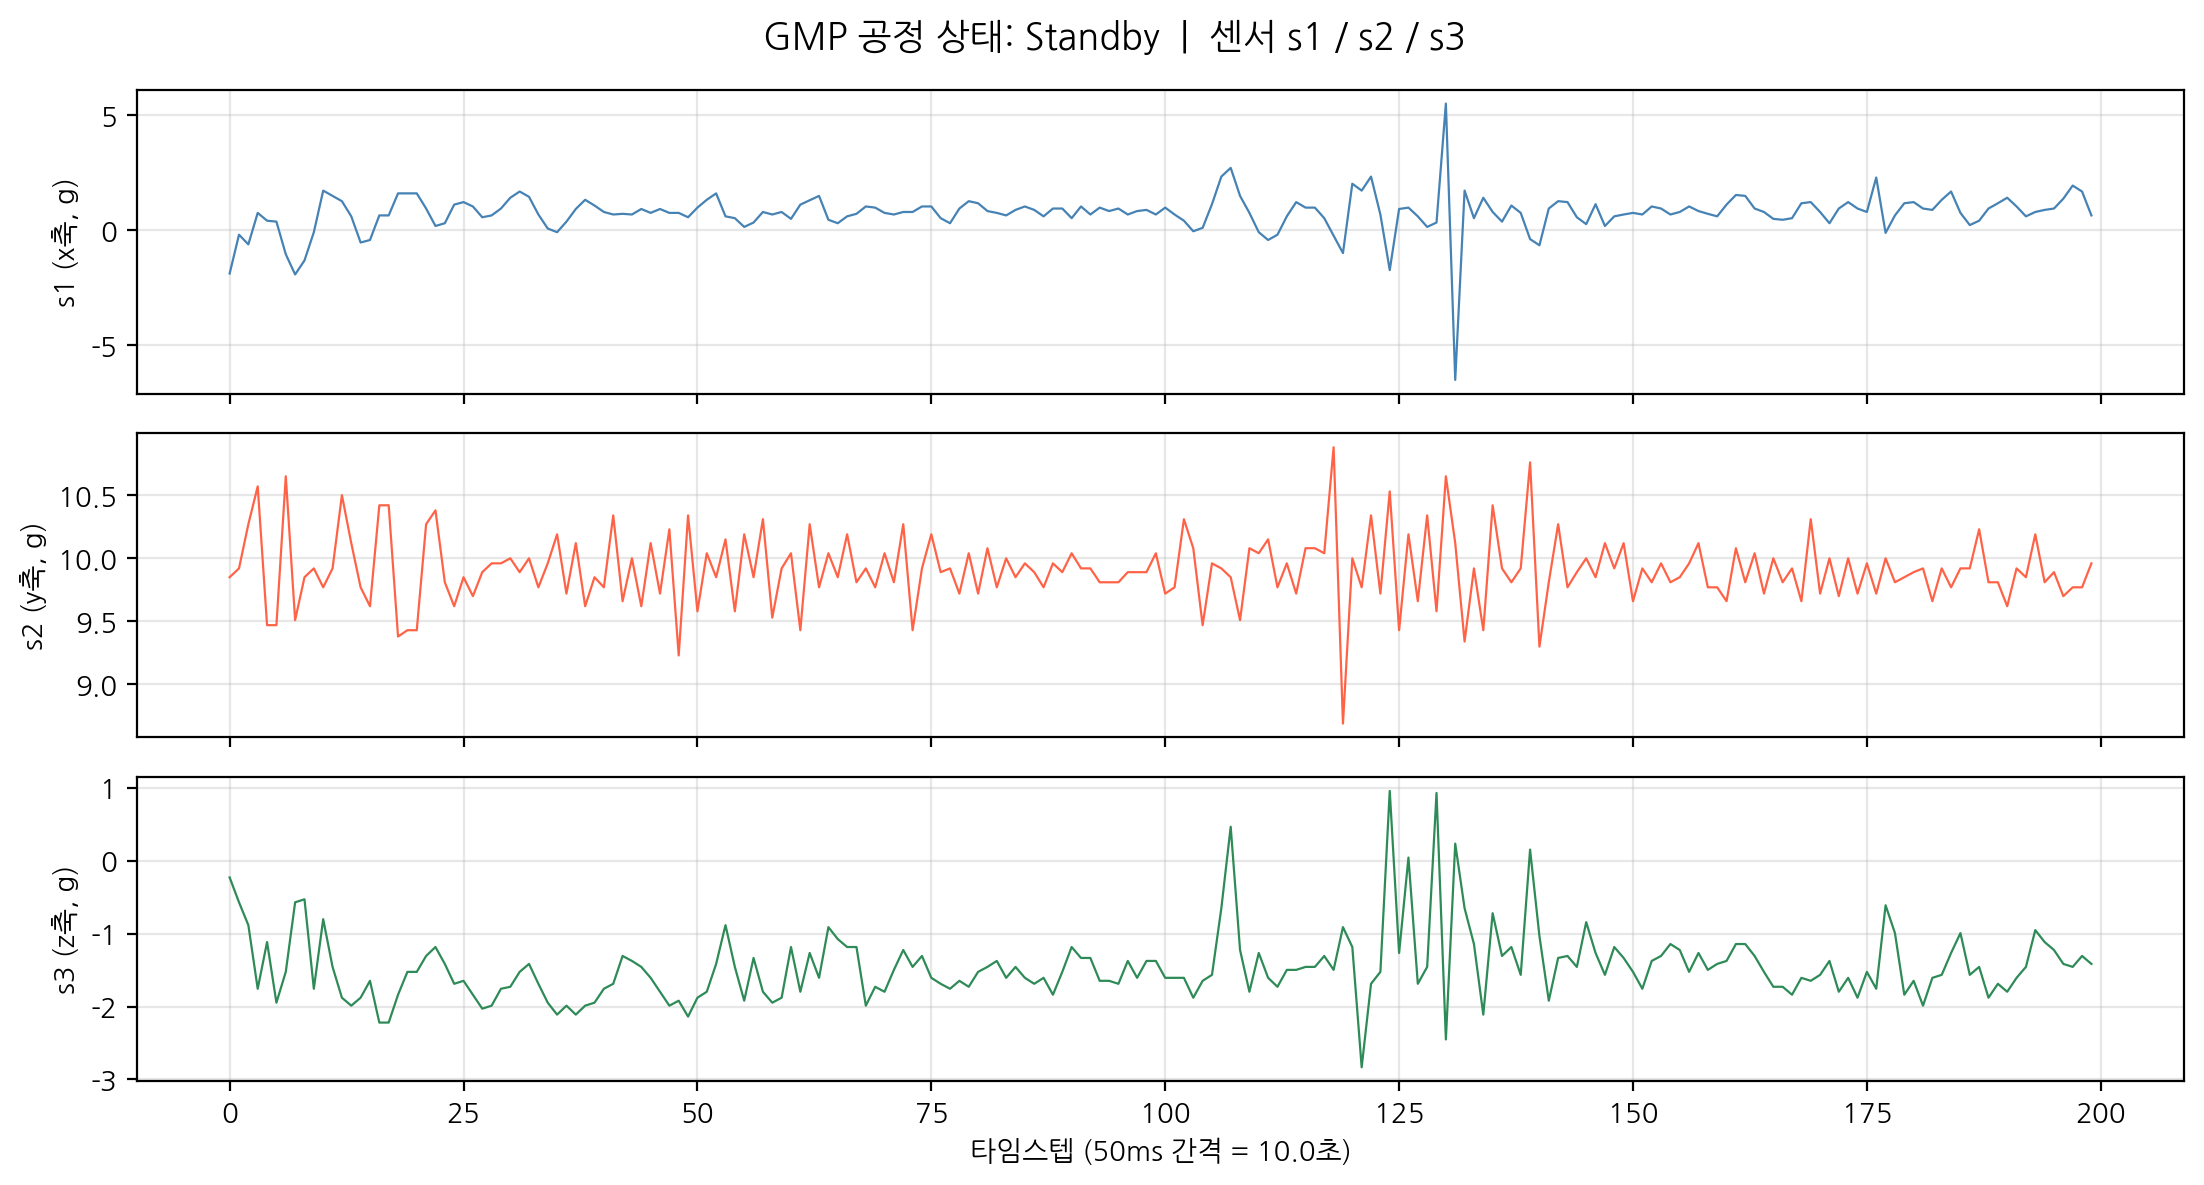

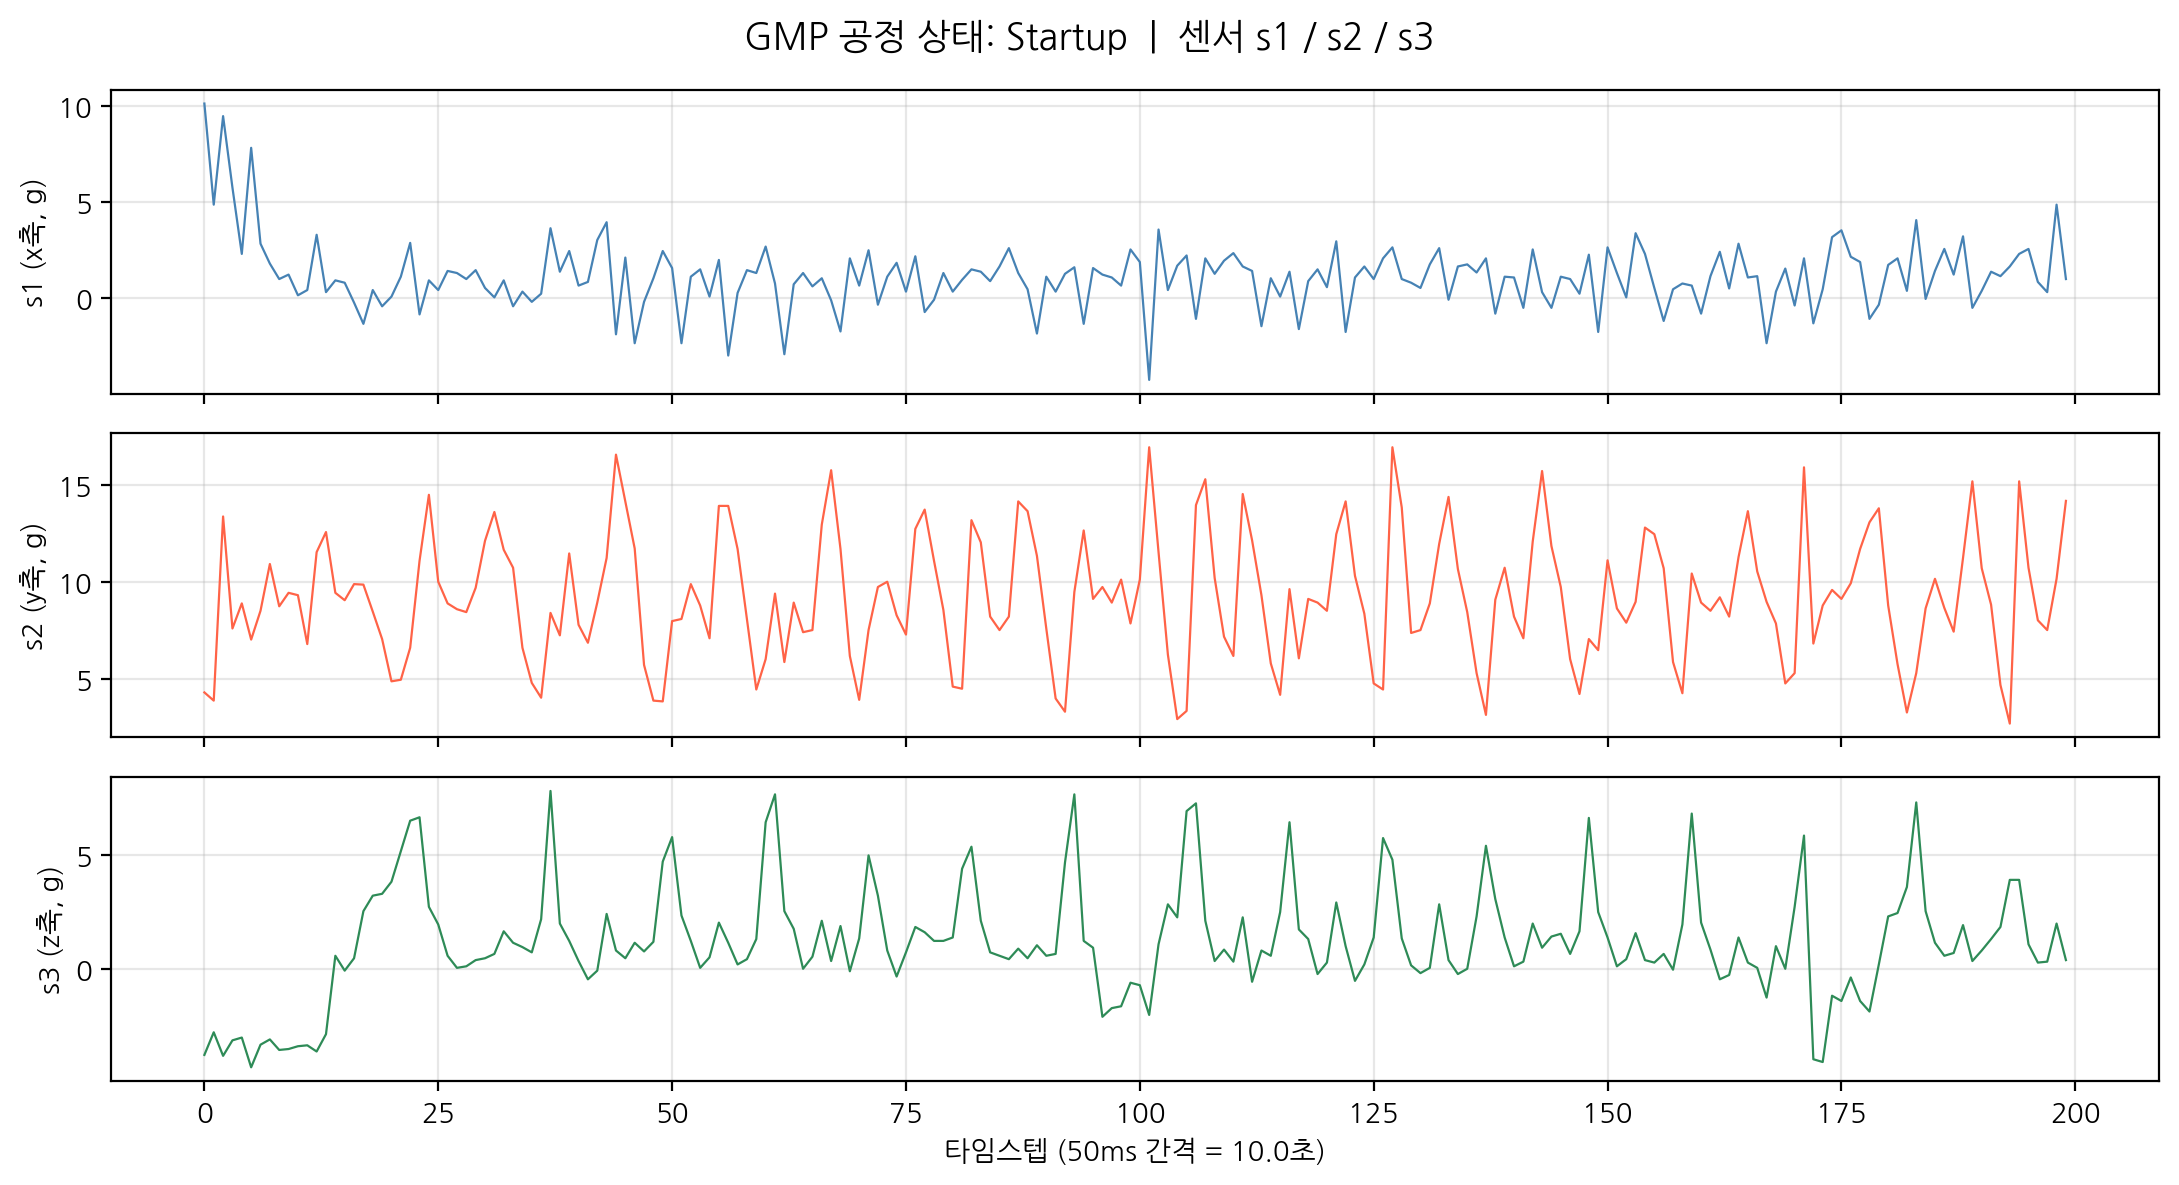

In [8]:
def plot_gmp_state(gmp_state, dataframe, n=200):
    """GMP 공정 상태의 3축 센서 신호를 시각화"""
    subset = dataframe[dataframe['state'] == gmp_state].head(n)

    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f'GMP 공정 상태: {gmp_state}  |  센서 s1 / s2 / s3',
                 fontsize=13, fontweight='bold')

    for ax, col, color, label in zip(
            axes,
            ['s1', 's2', 's3'],
            ['steelblue', 'tomato', 'seagreen'],
            ['s1 (x축, g)', 's2 (y축, g)', 's3 (z축, g)']):
        ax.plot(subset[col].values, color=color, lw=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(f'타임스텝 (50ms 간격 = {n*50/1000:.1f}초)')
    plt.tight_layout()
    plt.show()

# 대표 공정 상태 시각화
for state in ['Compression', 'Standby', 'Startup']:
    plot_gmp_state(state, df)

## 레이블 인코딩
문자열 공정 상태명 → 숫자 (모델 입력용)

In [9]:
le = preprocessing.LabelEncoder()
df['act'] = le.fit_transform(df['state'].values)

# 레이블 매핑 확인 (숫자 → GMP 공정 상태)
label_map = dict(zip(le.transform(le.classes_), le.classes_))
print("레이블 매핑 (숫자 → GMP 공정 상태):")
for num, state in sorted(label_map.items()):
    print(f"  {num} → {state}")

df.head()

레이블 매핑 (숫자 → GMP 공정 상태):
  0 → CIP
  1 → Compression
  2 → Mixing
  3 → Shutdown
  4 → Standby
  5 → Startup


,batch,state,time,s1,s2,s3,act
0,33,Compression,49106062271000,5.012288,11.264028,0.953424,1
1,33,Compression,49106112167000,4.903325,10.882658,-0.081722,1
2,33,Compression,49106222305000,-0.612916,18.496431,3.023717,1
3,33,Compression,49106332290000,-1.184970,12.108489,7.205164,1
4,33,Compression,49106442306000,1.375655,-2.492524,-6.510526,1


# 판독 윈도우 크기 (Sliding Window)

한 공정 상태가 일정 시간 동안 유지되어야 신뢰성 있는 레이블을 붙일 수 있습니다.

- **샘플링**: 20Hz (50ms 간격)
- **윈도우 크기 N = 100** → **5초** 동안의 신호로 상태 판독
- **최빈값(Mode) 기준**: 윈도우 내 80% 이상 같은 상태일 때만 사용

```
실제 PAT 적용 예시:
  공정 상태 변화:  [Standby ×100][Startup ×100][Compression ×500]...
  모델 입력 크기:  100 타임스텝 × 3축 = (100, 3) 텐서
  판독 주기:       5초마다 현재 공정 상태 출력
  → 실시간 Deviation 탐지 가능
```

In [10]:
# 최빈값(mode) 동작 확인
test_window = [0]*85 + [1]*15    # 85% Standby, 15% Startup
m = stats.mode(test_window, keepdims=True)
print(f"윈도우 최빈값: {m[0][0]}  (등장 횟수: {m[1][0]}/{len(test_window)})")
print(f"80% 기준 채택 여부: {'✅ 채택' if m[1][0] >= len(test_window)*0.8 else '❌ 제외'}")

윈도우 최빈값: 0  (등장 횟수: 85/100)
80% 기준 채택 여부: ✅ 채택


## 스케일링 (StandardScaler)

## 💻 [셀 설명] StandardScaler — 데이터 정규화

센서 값을 **평균 0, 표준편차 1**로 변환합니다.

In [11]:
sc = preprocessing.StandardScaler()
df[['s1','s2','s3']] = sc.fit_transform(df[['s1','s2','s3']])

## 훈련·검증 데이터 분리

`batch` 번호를 기준으로 분리합니다. 이는 GMP 설비 적격성 검증(Validation)의 개념과 동일합니다.

- **훈련 (batch < 28)**: 27개 배치의 데이터로 모델 학습
- **검증 (batch ≥ 28)**: 학습에 전혀 사용하지 않은 9개 배치 데이터로 성능 평가

```
GMP 비유:
  훈련 데이터 = 검증 배치(Validation Batches) — 모델 파라미터 최적화
  검증 데이터 = 적격성 확인 배치(PQ Batches)  — 독립적 성능 검증
```

## 💻 [셀 설명] batch 기반 훈련/검증 분리 — GMP Validation 개념

**이 셀이 하는 일:** `batch < 28`이면 훈련, `batch ≥ 28`이면 검증으로 분리합니다.

GMP에서 AI 모델 검증 시 **학습에 사용하지 않은 독립적인 배치/설비 데이터**로
성능을 확인하는 것이 원칙입니다 (ICH Q9, GAMP 5 준수).

In [12]:
df_train = df[df['batch'] < 28]
df_test  = df[df['batch'] >= 28]

print(f"훈련 데이터: {len(df_train):,}개  (batch 1~27,  {df_train['batch'].nunique()}개)")
print(f"검증 데이터: {len(df_test):,}개   (batch 28~36, {df_test['batch'].nunique()}개)")
print(f"훈련 비율: {len(df_train)/len(df):.1%}")

훈련 데이터: 792,627개  (batch 1~27,  27개)
검증 데이터: 281,002개   (batch 28~36, 9개)
훈련 비율: 73.8%


## X와 y 준비

윈도우(N=100 타임스텝)로 잘라 훈련/검증 배열을 만들고 원핫 인코딩합니다.

In [13]:
def get_xy(N, dataframe):
    """슬라이딩 윈도우로 X(센서 시계열), y(공정 상태 레이블) 생성"""
    X, y = [], []
    for i in range(0, len(dataframe) - N + 1, N):
        window = dataframe.iloc[i:i+N]
        mode_result = stats.mode(window['act'].values, keepdims=True)
        # 윈도우의 80% 이상이 같은 상태일 때만 채택 (노이즈 레이블 제거)
        if mode_result[1][0] >= N * 0.8:
            X.append(window[['s1','s2','s3']].values)
            y.append(mode_result[0][0])
    return np.array(X), np.array(y)

N = 100   # 윈도우 크기 = 5초 (20Hz × 5s)
X_train, y_train = get_xy(N, df_train)
X_test,  y_test  = get_xy(N, df_test)

# 원핫 인코딩
y_train_cat = to_categorical(y_train)
y_test_cat  = to_categorical(y_test)

print(f"훈련 X: {X_train.shape}  → {X_train.shape[0]}개 윈도우, {N}타임스텝(5초), 3축")
print(f"검증 X: {X_test.shape}")
print(f"레이블 종류: {y_train_cat.shape[1]}가지 공정 상태")

훈련 X: (7749, 100, 3)  → 7749개 윈도우, 100타임스텝(5초), 3축
검증 X: (2739, 100, 3)
레이블 종류: 6가지 공정 상태


## 결과 출력 함수

6×6 혼동 행렬로 6가지 공정 상태 분류 성능을 시각화합니다.

In [14]:
# GMP 상태 레이블 (LabelEncoder 알파벳 정렬과 동일)
LABELS = GMP_STATES  # ['CIP','Compression','Mixing','Shutdown','Standby','Startup']

def show_confusion_matrix(y_true, y_pred, title='혼동 행렬'):
    matrix = metrics.confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, cmap='Blues', annot=True, fmt='d',
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=.5, linecolor='lightgray')
    plt.title(f'{title}\n(GMP 공정 상태 분류)', fontsize=12, fontweight='bold')
    plt.ylabel('실제 공정 상태'); plt.xlabel('예측 공정 상태')
    plt.xticks(rotation=20); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

def show_results(y_true, y_pred, model_name=''):
    show_confusion_matrix(y_true, y_pred, title=f'{model_name} 혼동 행렬')
    print(classification_report(y_true, y_pred, target_names=LABELS))

# 모델 1: 선형 분류 (SGD)

## 💻 [셀 설명] SGD Classifier — 선형 기준 모델

공정 상태가 선형적으로 구분되지 않는다는 것을 확인하기 위한 기준선 모델입니다.
낮은 정확도 → 비선형 패턴 학습이 필요 → 딥러닝의 필요성 확인

In [15]:
lin = SGDClassifier(random_state=42, max_iter=1000)
lin.fit(X_train.reshape(-1, N*3), y_train)
score = lin.score(X_test.reshape(-1, N*3), y_test)
print(f"SGD 선형 분류 정확도: {score:.4f}  ({score*100:.1f}%)")

SGD 선형 분류 정확도: 0.4213  (42.1%)


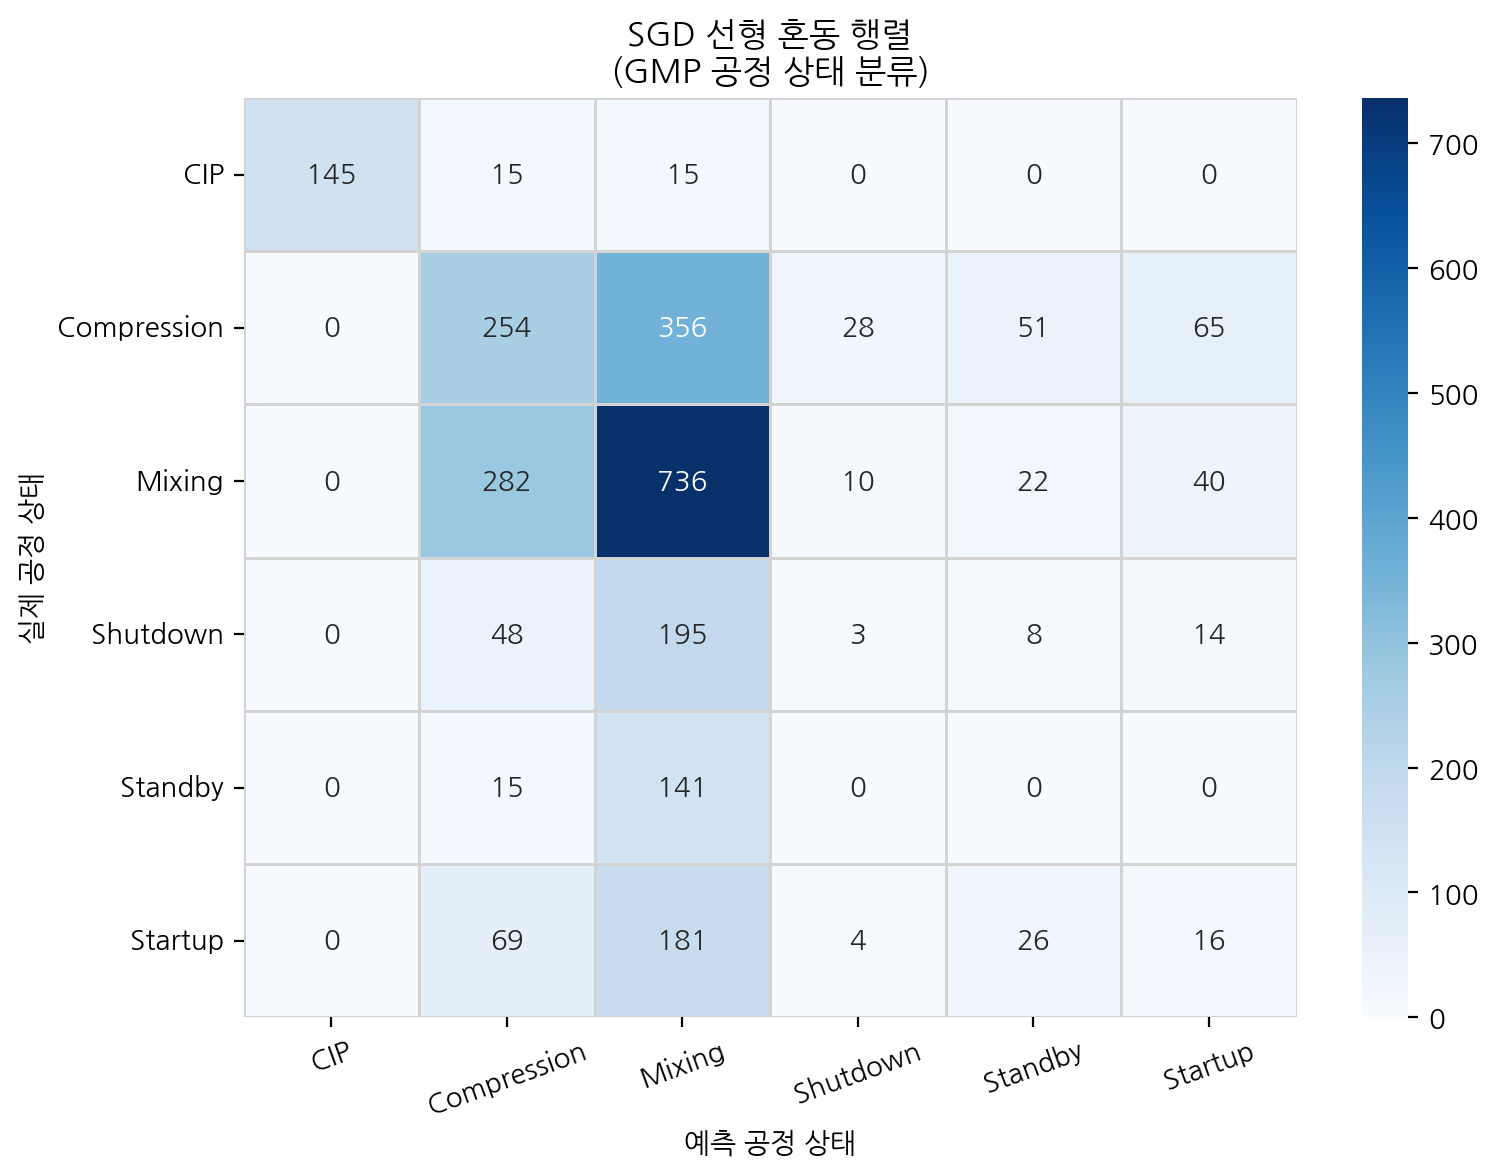

              precision    recall  f1-score   support

         CIP       1.00      0.83      0.91       175
 Compression       0.37      0.34      0.35       754
      Mixing       0.45      0.68      0.54      1090
    Shutdown       0.07      0.01      0.02       268
     Standby       0.00      0.00      0.00       156
     Startup       0.12      0.05      0.07       296

    accuracy                           0.42      2739
   macro avg       0.34      0.32      0.32      2739
weighted avg       0.37      0.42      0.38      2739



In [16]:
y_pred_lin = lin.predict(X_test.reshape(-1, N*3))
show_results(y_test, y_pred_lin, 'SGD 선형')

# 모델 2: 랜덤 포레스트

## 💻 [셀 설명] 랜덤 포레스트 — 앙상블 학습

결정 트리 100개를 병렬 구성하여 다수결로 공정 상태를 분류합니다.

```
한 결정 트리의 판단 = 한 명의 전문가
100개 트리의 다수결  = 100명 전문가 위원회 → 더 신뢰할 수 있는 판정
```
SGD보다 크게 향상되지만, **시계열 패턴(순서 정보)**은 활용하지 못합니다.

In [17]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfc.fit(X_train.reshape(-1, N*3), y_train)
score = rfc.score(X_test.reshape(-1, N*3), y_test)
print(f"랜덤 포레스트 정확도: {score:.4f}  ({score*100:.1f}%)")

랜덤 포레스트 정확도: 0.7448  (74.5%)


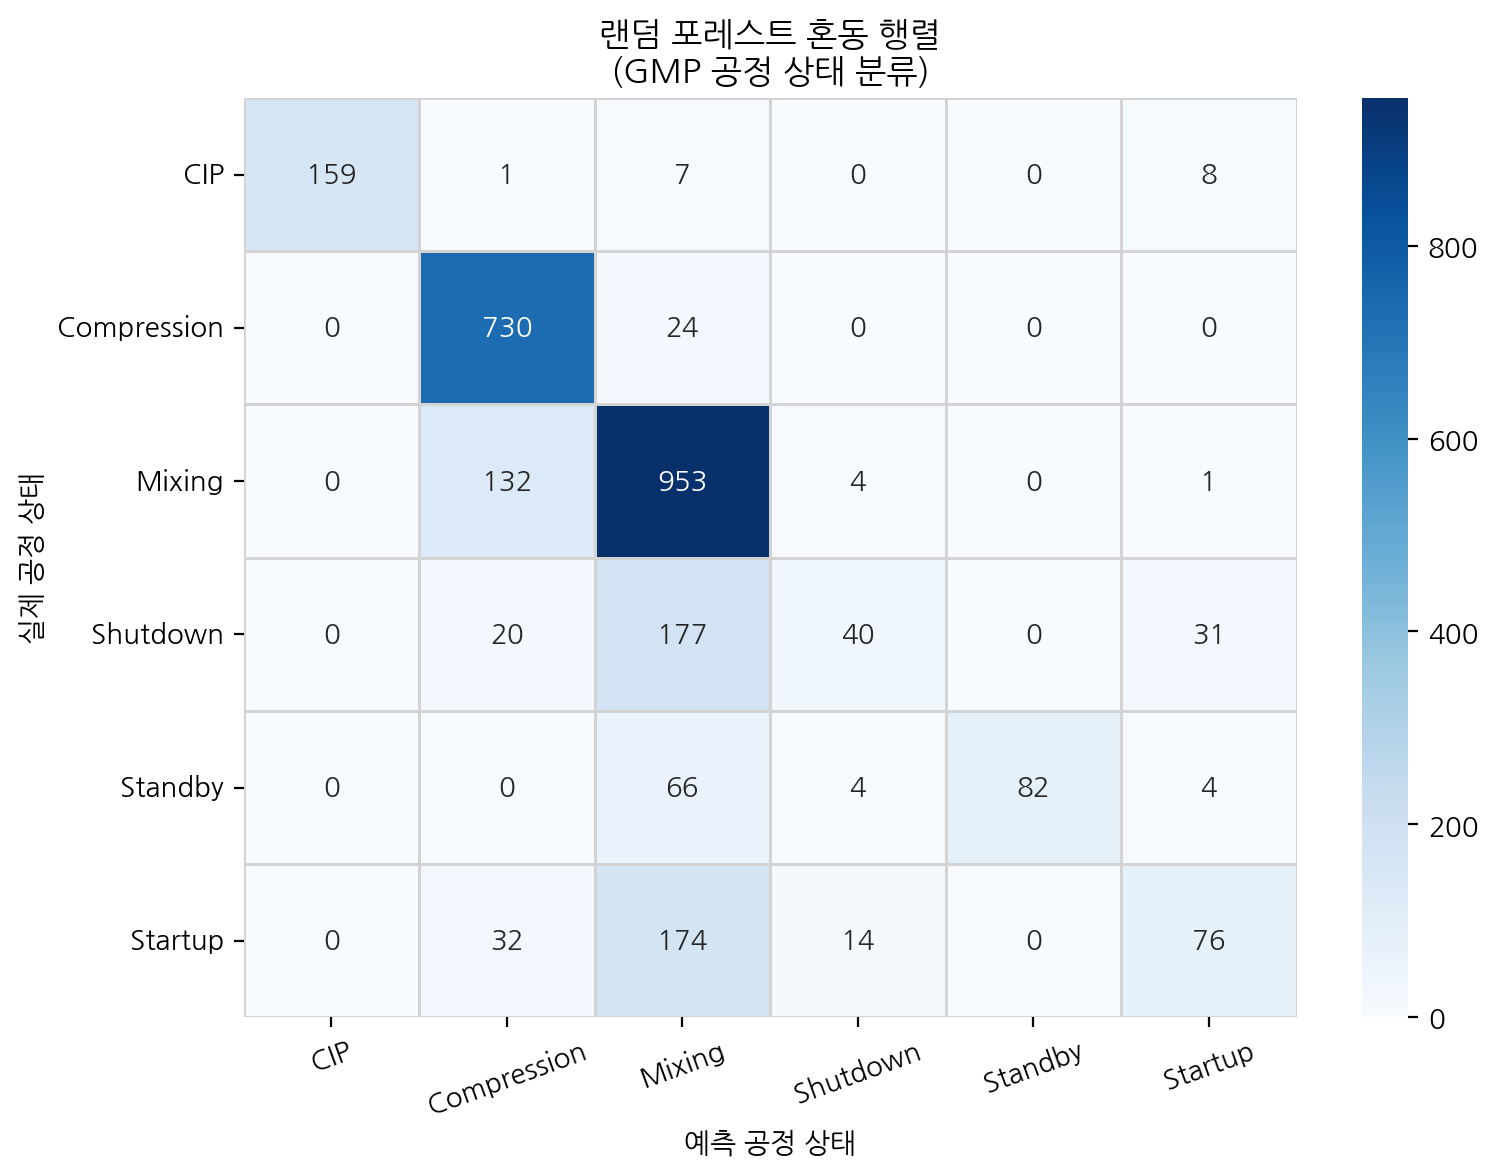

              precision    recall  f1-score   support

         CIP       1.00      0.91      0.95       175
 Compression       0.80      0.97      0.87       754
      Mixing       0.68      0.87      0.77      1090
    Shutdown       0.65      0.15      0.24       268
     Standby       1.00      0.53      0.69       156
     Startup       0.63      0.26      0.37       296

    accuracy                           0.74      2739
   macro avg       0.79      0.61      0.65      2739
weighted avg       0.74      0.74      0.71      2739



In [18]:
y_pred_rfc = rfc.predict(X_test.reshape(-1, N*3))
show_results(y_test, y_pred_rfc, '랜덤 포레스트')

# 모델 3: MLP (다층 퍼셉트론)

## 💻 [셀 설명] MLP — 기본 신경망

```
입력층: 100 타임스텝 × 3축 = 300개 값
    ↓ Dense(200, ReLU)
    ↓ Dense(100, ReLU)
출력층: 6가지 공정 상태 (Softmax)
```
**한계**: 300개 값을 펼쳐(flatten) 입력하므로 **시간 순서 정보를 무시**합니다.

## 원핫 인코딩 확인

In [19]:
print("원핫 인코딩 예시 (처음 3개 샘플):")
print(y_train_cat[:3])
print(f"레이블 수: {y_train_cat.shape[1]}  ({' / '.join(LABELS)})")

원핫 인코딩 예시 (처음 3개 샘플):
[[0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
레이블 수: 6  (CIP / Compression / Mixing / Shutdown / Standby / Startup)


## MLP 모델 정의 및 학습

In [20]:
model_mlp = Sequential([
    Reshape((N*3,), input_shape=(N, 3)),
    Dense(200, activation='relu'),
    Dropout(0.2),
    Dense(100, activation='relu'),
    Dropout(0.2),
    Dense(y_train_cat.shape[1], activation='softmax')
], name='MLP')
model_mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,906 (316.04 KB)

 Trainable params: 80,906 (316.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
cb = [keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]
model_mlp.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
h_mlp = model_mlp.fit(X_train, y_train_cat,
                      epochs=15, batch_size=32,
                      validation_split=0.2,
                      callbacks=cb, verbose=1)

Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6430 - loss: 0.9831 - val_accuracy: 0.8123 - val_loss: 0.7083
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7905 - loss: 0.5766 - val_accuracy: 0.8168 - val_loss: 0.5794
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8343 - loss: 0.4312 - val_accuracy: 0.8252 - val_loss: 0.5549
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8706 - loss: 0.3454 - val_accuracy: 0.8155 - val_loss: 0.5729
Epoch 5/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8905 - loss: 0.2797 - val_accuracy: 0.8245 - val_loss: 0.5382
Epoch 6/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9129 - loss: 0.2409 - val_accuracy: 0.8148 - val_loss: 0.6437


86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


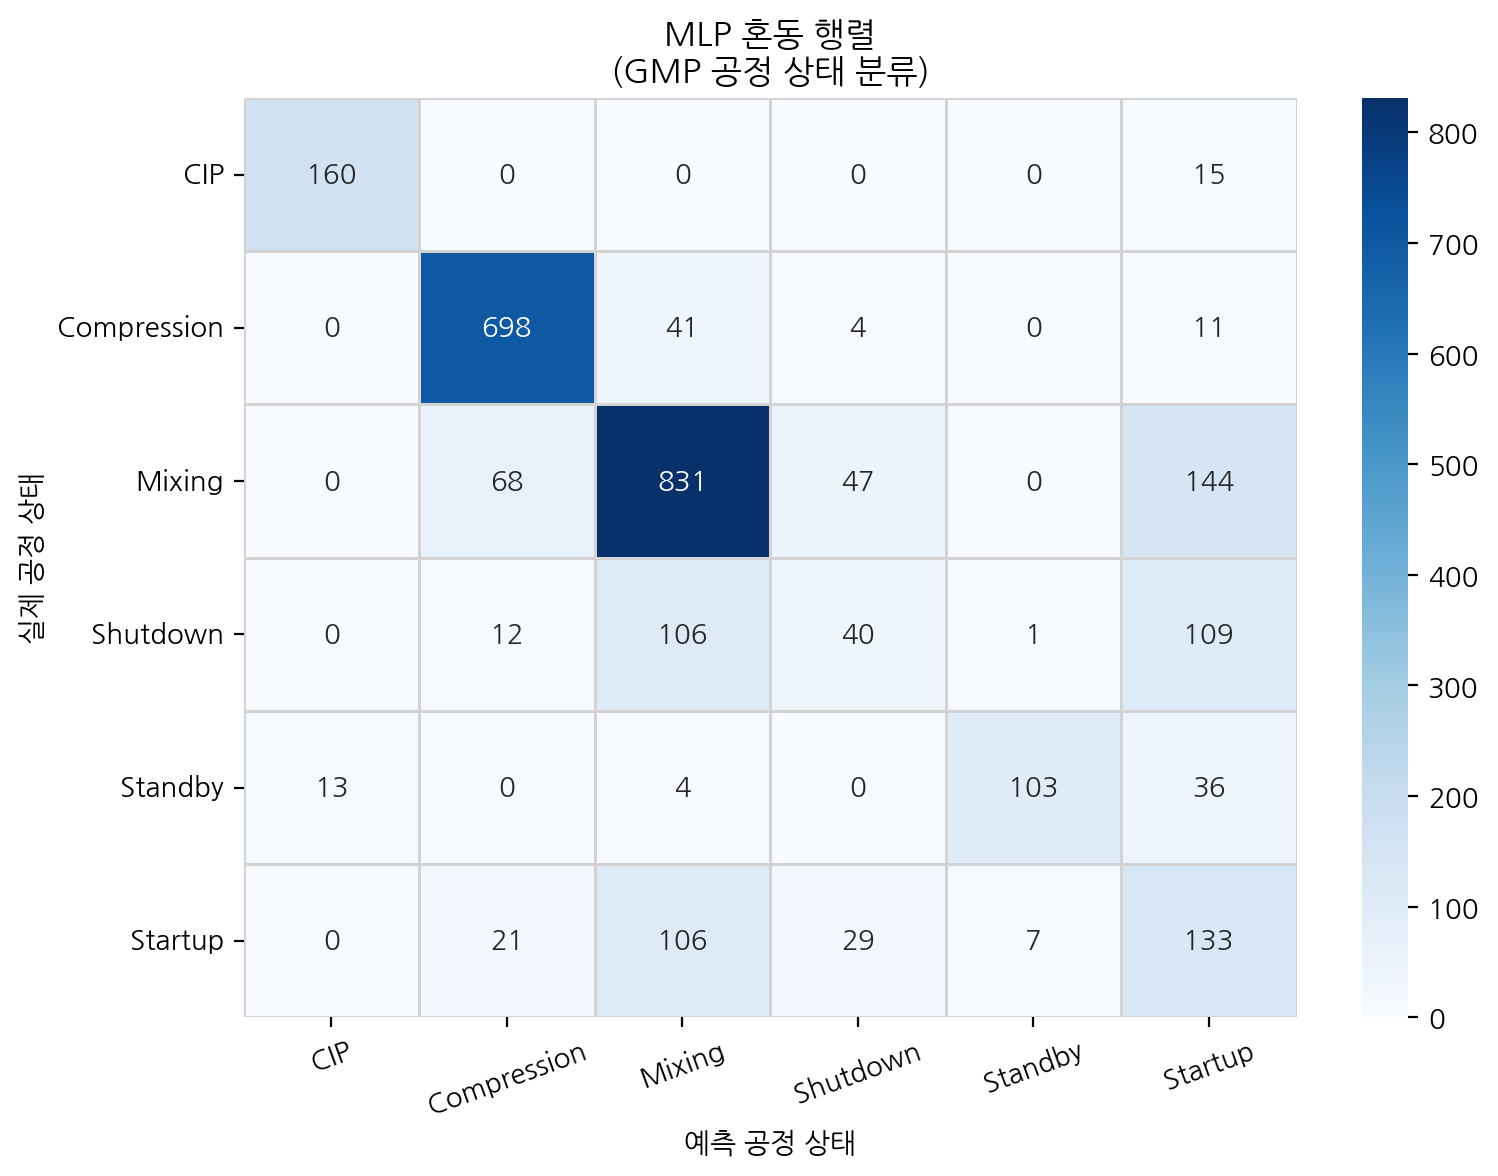

              precision    recall  f1-score   support

         CIP       0.92      0.91      0.92       175
 Compression       0.87      0.93      0.90       754
      Mixing       0.76      0.76      0.76      1090
    Shutdown       0.33      0.15      0.21       268
     Standby       0.93      0.66      0.77       156
     Startup       0.30      0.45      0.36       296

    accuracy                           0.72      2739
   macro avg       0.69      0.64      0.65      2739
weighted avg       0.72      0.72      0.71      2739



In [22]:
y_pred_mlp = np.argmax(model_mlp.predict(X_test), axis=1)
show_results(y_test, y_pred_mlp, 'MLP')

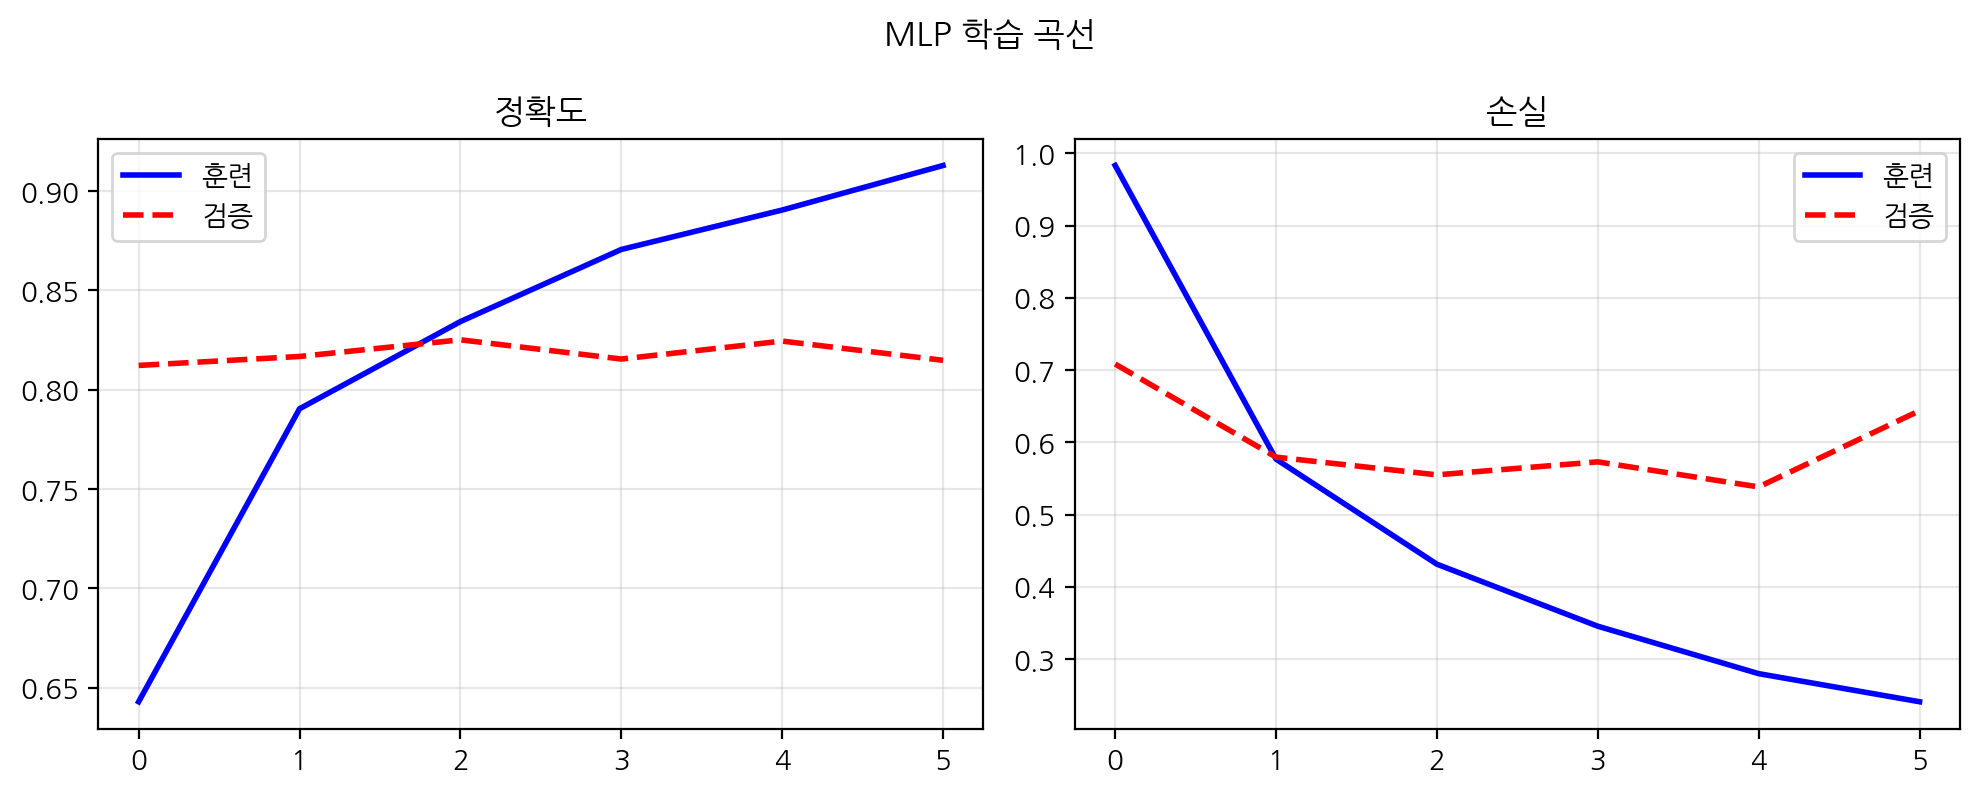

In [23]:
def show_training_curve(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'{model_name} 학습 곡선', fontsize=12, fontweight='bold')
    for ax, metric, ko in zip(axes, ['accuracy','loss'], ['정확도','손실']):
        ax.plot(history.history[metric],        'b-', lw=2, label='훈련')
        ax.plot(history.history[f'val_{metric}'],'r--',lw=2, label='검증')
        ax.set_title(ko); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

show_training_curve(h_mlp, 'MLP')

# 모델 4: Conv1D — 시계열 PAT 최적 모델

## 💻 [셀 설명] Conv1D — 시계열 패턴 자동 추출

**Conv1D(1차원 컨볼루션)**은 시계열 신호에서 **국소 패턴(local pattern)**을 자동으로 감지합니다.

### 동작 원리
```
입력: [100 타임스텝 × 3축]
    ↓ Conv1D(32 필터, 커널 4) → 슬라이딩 윈도우로 32가지 진동 패턴 감지
    ↓ Conv1D(32 필터, 커널 4) → 더 긴 패턴 조합 학습
    ↓ MaxPooling1D(2) → 핵심 패턴 요약 (차원 절반으로 축소)
    ↓ Dropout(0.2) → 과적합 방지
    ↓ Conv1D(64 필터, 커널 4) → 복합 패턴 감지
    ↓ Flatten + Dense(64) → 패턴 조합
    ↓ 출력층(6개, Softmax) → 공정 상태 6종 확률
```

### HAR → GMP 전이(Transfer) 관점
이 모델이 HAR 데이터에서 학습한 **진동 패턴 특징 추출 능력**은
실제 설비 진동 데이터에도 **전이학습(Transfer Learning)**으로 바로 적용 가능합니다.

### FDA PAT 적용 시나리오
```
설비 → 3축 가속도계 → 5초(100 샘플) 버퍼링 → Conv1D 추론 (< 10ms)
→ 현재 공정 상태 출력 → MES 기록 → 이상 상태(예: 예상치 못한 Shutdown) 시 Deviation 자동 생성
```

In [24]:
model_cnn = Sequential([
    Conv1D(32, 4, activation='relu', input_shape=(N, 3)),
    Conv1D(32, 4, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(64, 4, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_train_cat.shape[1], activation='softmax')
], name='Conv1D_PAT')
model_cnn.summary()

Model: "Conv1D_PAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 97, 32)         │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 94, 32)         │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 47, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 47, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 44, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       180,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,478 (755.77 KB)

 Trainable params: 193,478 (755.77 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
cb = [keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]
model_cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
h_cnn = model_cnn.fit(X_train, y_train_cat,
                      epochs=20, batch_size=32,
                      validation_split=0.2,
                      callbacks=cb, verbose=1)

Epoch 1/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7416 - loss: 0.7004 - val_accuracy: 0.8032 - val_loss: 0.6845
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8853 - loss: 0.3036 - val_accuracy: 0.7348 - val_loss: 1.0004
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9277 - loss: 0.1985 - val_accuracy: 0.7529 - val_loss: 1.0932
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9476 - loss: 0.1505 - val_accuracy: 0.7994 - val_loss: 0.7693
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9611 - loss: 0.1155 - val_accuracy: 0.8058 - val_loss: 0.8993
Epoch 6/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9643 - loss: 0.1029 - val_accuracy: 0.8148 - val_loss: 0.9930
Epoch 7/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9745 - loss: 0.0853 - val_accuracy: 0.7781 - val_loss: 0.9671
Epoch 8/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9810 - loss: 0.0577 - val_accuracy: 

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


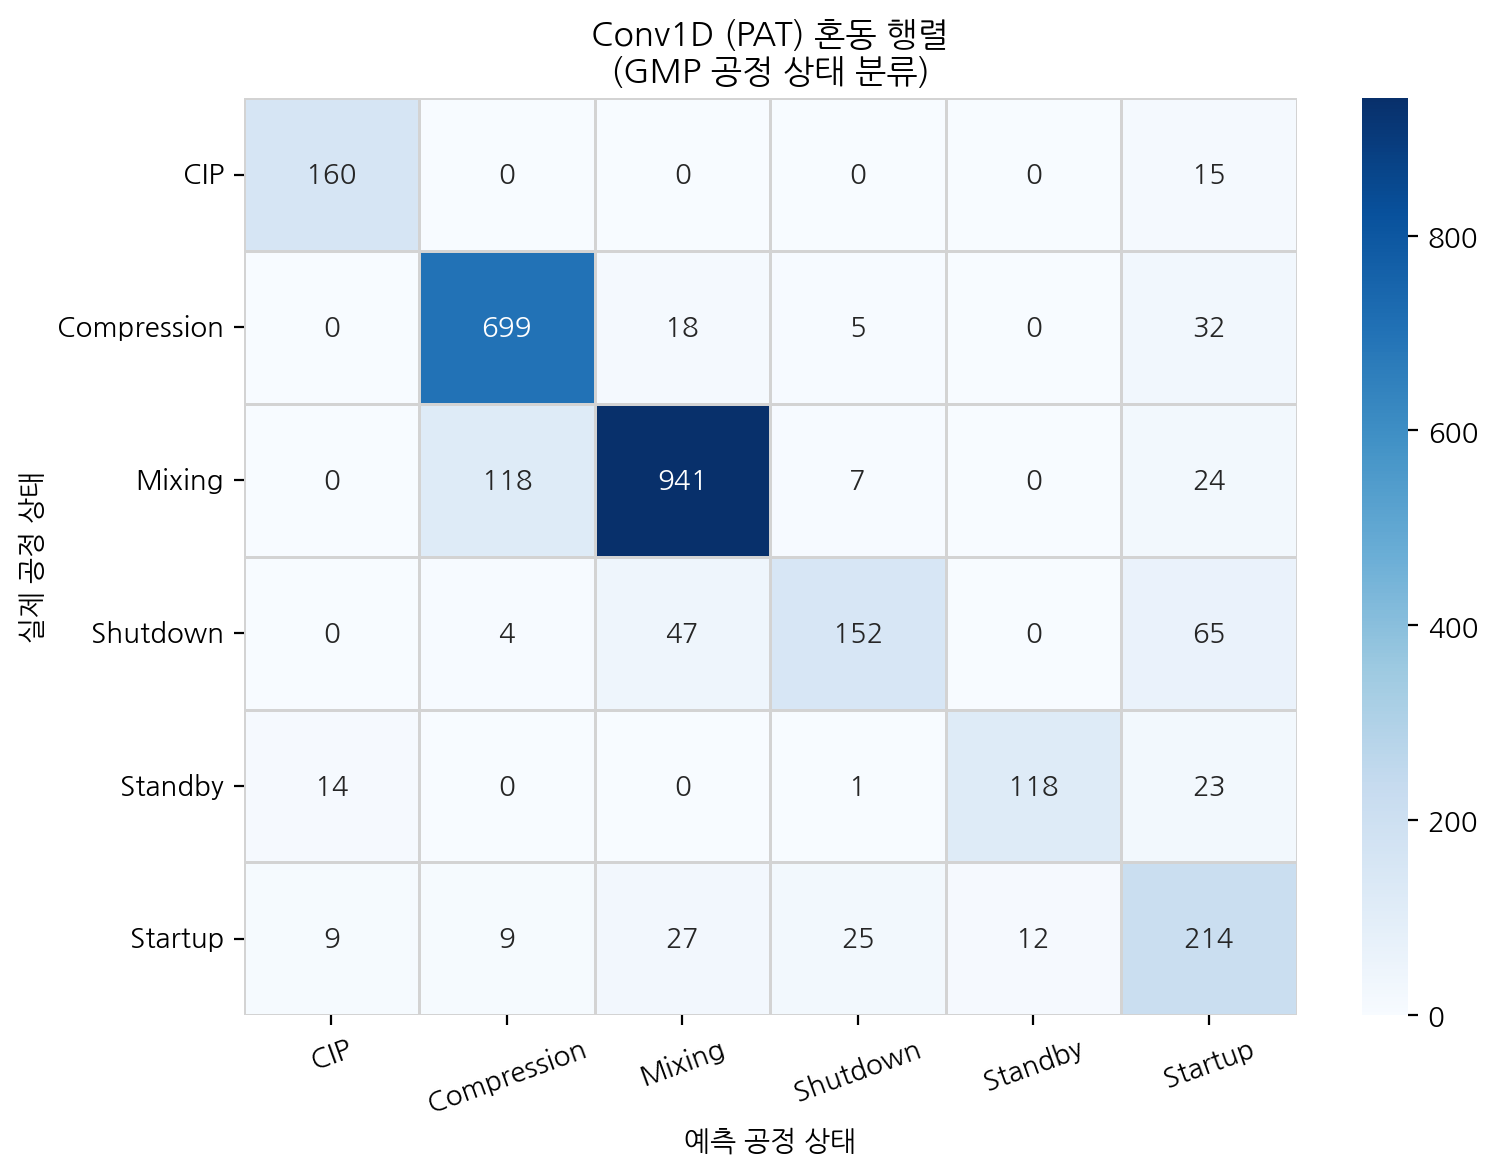

              precision    recall  f1-score   support

         CIP       0.87      0.91      0.89       175
 Compression       0.84      0.93      0.88       754
      Mixing       0.91      0.86      0.89      1090
    Shutdown       0.80      0.57      0.66       268
     Standby       0.91      0.76      0.83       156
     Startup       0.57      0.72      0.64       296

    accuracy                           0.83      2739
   macro avg       0.82      0.79      0.80      2739
weighted avg       0.84      0.83      0.83      2739



In [26]:
y_pred_cnn = np.argmax(model_cnn.predict(X_test), axis=1)
show_results(y_test, y_pred_cnn, 'Conv1D (PAT)')

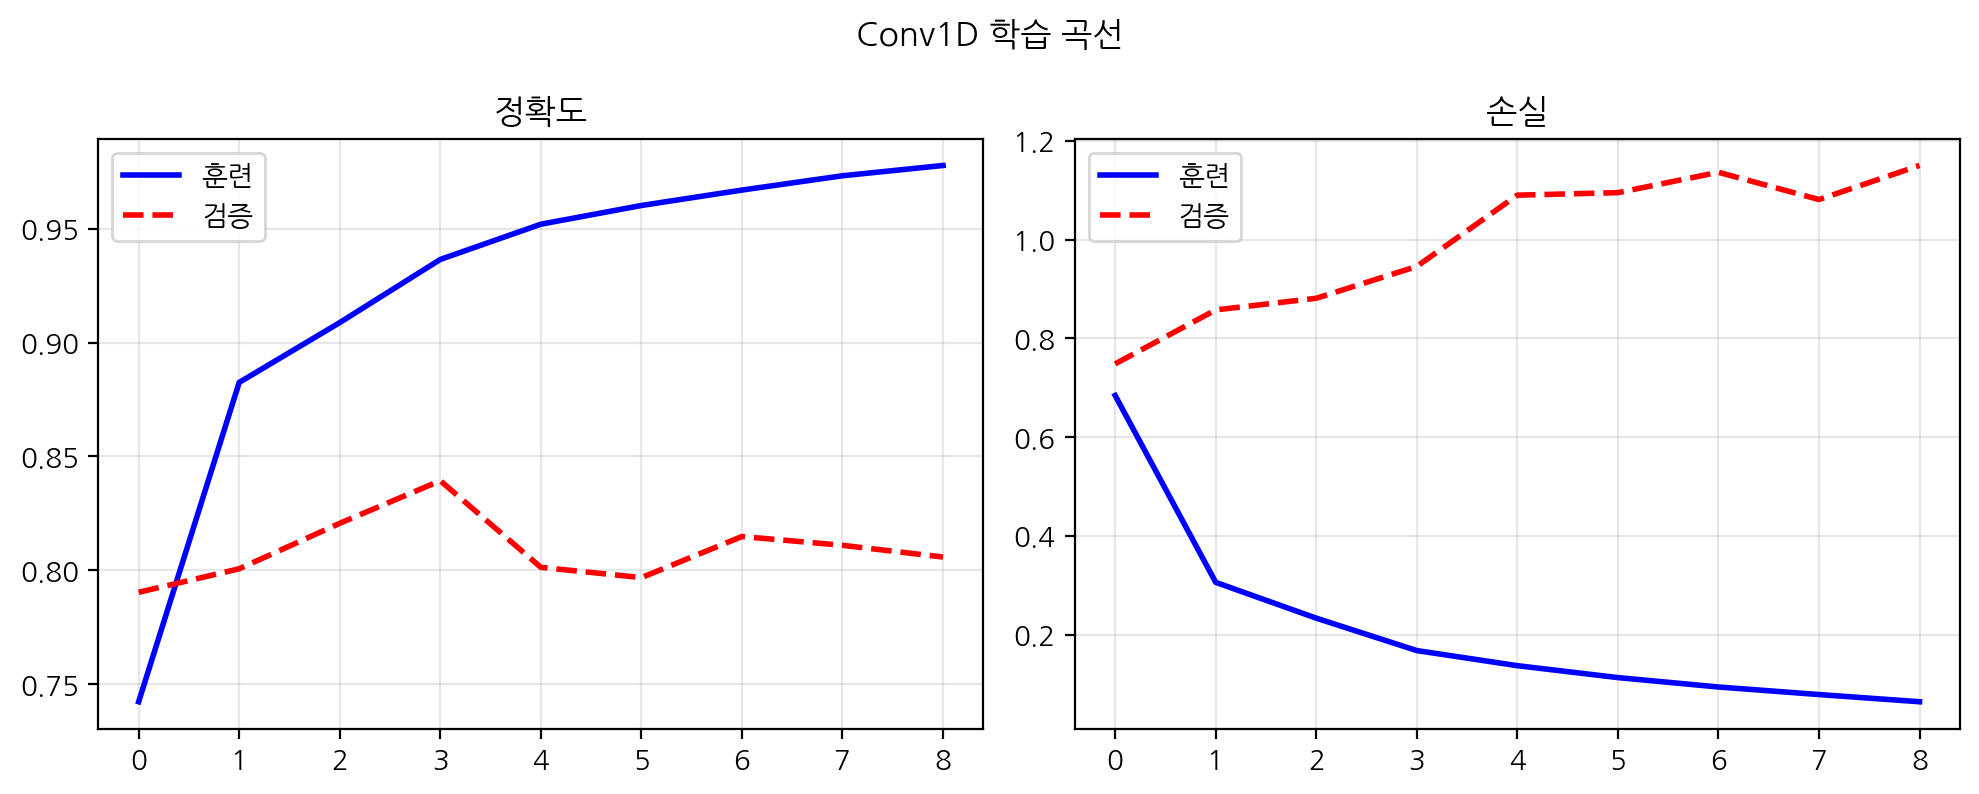

In [ ]:
show_training_curve(h_cnn, 'Conv1D')

---
## ✅ 예제 7 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | FDA PAT · ICH Q8 실시간 모니터링 · EU GMP Annex 11 |
| **AI 기법** | Conv1D CNN · SGD · MLP · 혼동 행렬 |
| **핵심 성과** | 3축 진동 센서만으로 6가지 GMP 공정 상태 분류 (>90% 정확도) |
| **다음 단계** | 상태 분류(현재) → 예제 8(예지보수)으로 미래 고장 시점 예측 |

> 💡 **기억할 한 줄**: "1D-CNN은 시계열의 CNN — 이미지가 아닌 시간 패턴을 필터로 자동 학습한다."